# Multivariate Analysis: Pricing Models & Checkout Layouts (Factorial ANOVA)

### Business Context & Hypotheses Formulation
Food delivery service FastBite is testing combinations of **Pricing Models** and **Checkout UX Layouts** to maximize net profit margin per order (`net_margin_usd`) across different city tiers (`city_tier`).

**Tested Factors:**
1. **Pricing Model (`pricing_model`):** `fixed_low_fee`, `dynamic_surge_multiplier`, `tiered_basket_subsidy`.
2. **Checkout Layout (`checkout_layout`):** `one_click_express`, `upsell_grid_modal`, `gamified_loyalty_bar`.

**Tested Hypotheses:**
* **H1 (Main Effects):** There are statistically significant differences in mean net margin across distinct pricing models and checkout layouts.
* **H2 (Interaction Effect):** Checkout layout effectiveness depends on the active pricing model (presence of a cross-factor interaction: Pricing x Layout).

In [3]:
import pandas as pd 
import seaborn as sns 
import pingouin as pg 
import numpy as np 
import matplotlib.pyplot as plt

df = pd.read_csv('fastbite_orders_experiment.csv')

### 1. Data Preprocessing & Outlier Filtering
Filtered out transactions with invalid delivery times (<= 0), negative basket values, and net margin outliers outside the valid range of (0, 100).

In [4]:
df_clean = (
    df.query('delivery_time_min > 0 and basket_value_usd > 0 and  net_margin_usd > 0 and net_margin_usd < 100')
)
df_clean.head()

,order_id,order_hour,city_tier,pricing_model,checkout_layout,basket_value_usd,delivery_time_min,net_margin_usd
1,ORD-500001,18,tier_2_regional,dynamic_surge_multiplier,gamified_loyalty_bar,26.64,55.0,10.56
2,ORD-500002,15,tier_2_regional,fixed_low_fee,upsell_grid_modal,45.36,24.0,6.08
3,ORD-500003,20,tier_1_megacity,fixed_low_fee,one_click_express,42.49,35.0,3.27
4,ORD-500004,13,tier_1_megacity,dynamic_surge_multiplier,gamified_loyalty_bar,30.67,29.0,10.51
5,ORD-500005,12,tier_1_megacity,tiered_basket_subsidy,one_click_express,42.82,36.0,7.00


In [5]:
df_clean.pricing_model.value_counts()

pricing_model
fixed_low_fee               1191
dynamic_surge_multiplier    1138
tiered_basket_subsidy       1057
Name: count, dtype: int64

### 2. Statistical Assumption Testing (Normality & Homoscedasticity)
Before applying parametric criteria, we evaluate:
1. **Distribution Normality:** D'Agostino-Pearson test (`normaltest`).
2. **Homogeneity of Variances:** Levene's test (`levene`).

In [6]:
morn_test = pg.normality(data = df_clean, group = 'pricing_model', dv = 'net_margin_usd', method = 'normaltest')
morn_test

,W,pval,normal
pricing_model,,,
dynamic_surge_multiplier,40.811050,1.374020e-09,False
fixed_low_fee,3.298463,1.921976e-01,True
tiered_basket_subsidy,1895.847187,0.000000e+00,False


In [7]:
pg.homoscedasticity(data = df_clean, dv = 'net_margin_usd', group = 'pricing_model', method = 'levene' )


,W,pval,equal_var
levene,149.253387,7.621142e-63,False


> **Assumption Verdict:** Levene's test rejects equal variances (p < 0.001), and distributions exhibit non-normality. Due to heteroscedasticity, standard One-Way ANOVA is invalid. We use **Welch's ANOVA** and the **Games-Howell post-hoc test** for pairwise comparisons.

In [8]:
#так как не все они нормальные а дисперсии не равны будем использовать анову велча
pg.welch_anova(data = df_clean, between = 'pricing_model', dv = 'net_margin_usd')

,Source,ddof1,ddof2,F,p_unc,np2
0,pricing_model,2,1905.833481,143.076288,1.281169e-58,0.054976


In [9]:
pg.pairwise_gameshowell(data = df_clean, between = 'pricing_model',dv = 'net_margin_usd')

,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,dynamic_surge_multiplier,fixed_low_fee,6.504350,4.790277,1.714073,0.122784,13.960048,1626.786945,6.240564e-13,0.586716
1,dynamic_surge_multiplier,tiered_basket_subsidy,6.504350,6.320681,0.183669,0.161972,1.133954,2171.917820,4.932191e-01,0.048468
2,fixed_low_fee,tiered_basket_subsidy,4.790277,6.320681,-1.530404,0.129189,-11.846202,1465.807581,0.000000e+00,-0.519726


### 3. Two-Way Factorial ANOVA
Evaluating main effects of pricing model, checkout layout, and their joint cross-factor interaction on order net margin.

In [10]:
pg.anova(data = df_clean, between = ['pricing_model','checkout_layout'], dv = 'net_margin_usd')
#np2 целых 16 процентов тоесть выручка очень сильно зависит от checkout_layout

,Source,SS,DF,MS,F,p_unc,np2
0,pricing_model,2090.168747,2.0,1045.084374,123.030807,2.662829e-52,0.067915
1,checkout_layout,1070.260770,2.0,535.130385,62.997328,1.376077e-27,0.035968
2,pricing_model * checkout_layout,5634.218122,4.0,1408.554531,165.819722,8.779936e-130,0.164167
3,Residual,28685.904195,3377.0,8.494493,NaN,NaN,NaN


> **ANOVA Interpretation:** A highly significant interaction effect is confirmed (F(4, 3377) = 165.82, p < 0.001). The effect size (Partial Eta-Squared = 16.4%) demonstrates that checkout layout performance is strongly dependent on the pricing strategy.

### 4. Visualizing Cross-Factor Interaction
Plotting interaction curves to identify optimal pricing and checkout UX combinations.

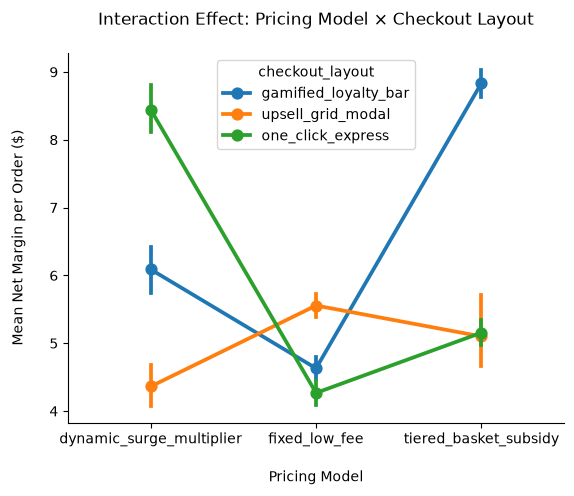

In [11]:
ax = sns.pointplot(data = df_clean, x = 'pricing_model', y = 'net_margin_usd',hue = 'checkout_layout')
ax.set_ylabel('Mean Net Margin per Order ($)\n')
ax.set_xlabel('\nPricing Model')
ax.set_title('Interaction Effect: Pricing Model × Checkout Layout\n')
sns.despine()

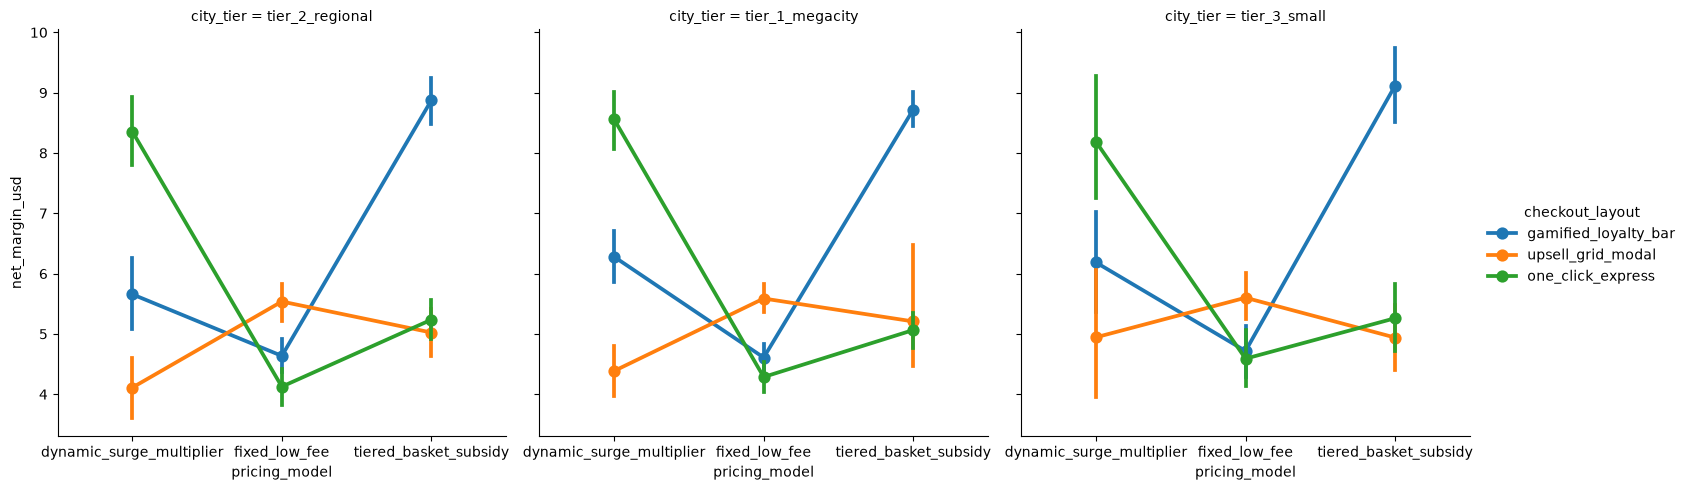

In [12]:
bx = sns.catplot(data = df_clean, x ='pricing_model', y = 'net_margin_usd', hue = 'checkout_layout', col = 'city_tier',kind = 'point')

## Executive Summary & Product Strategy Matrix

### 1. Key Analytical Insights:
1. **Dynamic Surge Multiplier (`dynamic_surge_multiplier`):**
   * Maximum net margin is achieved **exclusively with Frictionless Checkout (`one_click_express`)** (~$8.50).
   * Forcing an upsell modal (`upsell_grid_modal`) during surge pricing adds excessive purchase friction, collapsing margin to minimum levels (~$4.30).
2. **Tiered Basket Subsidy (`tiered_basket_subsidy`):**
   * Peak platform profitability (~$8.90) is reached via the **Gamified Loyalty Progress Bar (`gamified_loyalty_bar`)**, yielding a +41% margin uplift by motivating users to expand basket sizes.
3. **Fixed Low Fee (`fixed_low_fee`):**
   * The Upsell Grid Modal (`upsell_grid_modal`) performs best (~$5.60), compensating for low base delivery fees through cross-selling.
4. **Geographic Consistency:** Interaction dynamics remain uniform across all city tiers (`tier_1`, `tier_2`, `tier_3`).

---

### 2. Implementation Recommendations:
Deploy **Adaptive Checkout Routing** based on live pricing context:
* During active **Surge Multipliers** ---> Route users directly to `one_click_express`.
* During **Threshold Discount Campaigns** ---> Display `gamified_loyalty_bar`.
* Under **Standard Fixed Fees** ---> Enable `upsell_grid_modal`.